# Part 3: PageRank on Spark

**Dataset:** `small.txt` (53 nodes) and `whole.txt` (1000 nodes, 8192 edges)  
**Source:** https://github.com/pnijhara/PySpark-PageRank/tree/main/graph

**Algorithm:** Iterative PageRank with teleportation


## 1. Spark Setup

In [1]:
from pyspark.sql import SparkSession
import time

# Initialize Spark
spark = SparkSession.builder \
    .appName("PageRank") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("SparkContext:", sc)

Spark version: 4.0.2
SparkContext: <SparkContext master=local[*] appName=PageRank>


## 2. Data Loading



In [2]:
def load_graph(filepath: str):
    raw = sc.textFile(filepath)

    # Parse lines → (src, dst) pairs; filter blank lines
    edges = raw \
        .filter(lambda line: line.strip() != '') \
        .map(lambda line: tuple(map(int, line.strip().split())))

    # De-duplicate edges: distinct() removes repeated (src, dst) pairs
    edges = edges.distinct()

    # Build adjacency list: group destinations by source
    links_rdd = edges \
        .groupByKey() \
        .mapValues(list)

    # Count unique nodes (both sources and destinations)
    srcs  = edges.map(lambda e: e[0])
    dsts  = edges.map(lambda e: e[1])
    n     = srcs.union(dsts).distinct().count()

    # Persist links_rdd — it's used in every iteration
    links_rdd = links_rdd.cache()

    return links_rdd, n


print("load_graph() defined.")

load_graph() defined.


## 3. PageRank Algorithm

In [3]:
def run_pagerank(links_rdd, n: int, beta: float = 0.8, num_iter: int = 40):

    teleport = (1.0 - beta) / n   # constant teleportation contribution per node

    # Step 1: Initialize ranks r0 = (1/n) * A
    # Every node starts with equal rank 1/n
    ranks_rdd = links_rdd.mapValues(lambda _: 1.0 / n)

    print(f"  PageRank initialized: n={n}, beta={beta}, iterations={num_iter}")
    print(f"  Initial rank per node: {1.0/n:.8f}")
    print(f"  Teleport constant per iteration: {teleport:.8f}")
    print()

    # Steps 2–4: Iterative update
    for i in range(num_iter):

        # JOIN: pair each node's adjacency list with its current rank
        # Result: (node, ([neighbors], rank))
        joined = links_rdd.join(ranks_rdd)
        contributions = joined.flatMap(
            lambda x: [
                (neighbor, x[1][1] / len(x[1][0]))
                for neighbor in x[1][0]
            ]
        )

        # REDUCE: sum all contributions received by each node

        summed = contributions.reduceByKey(lambda a, b: a + b)

        ranks_rdd = summed.mapValues(lambda contrib: teleport + beta * contrib)
        if (i + 1) % 10 == 0:
            ranks_rdd = ranks_rdd.cache()

            _ = ranks_rdd.count()
            print(f"  Checkpoint at iteration {i + 1}")

    return ranks_rdd


print("run_pagerank() defined.")

run_pagerank() defined.


## 4. Reporting Function

In [4]:
def report_pagerank(ranks_rdd, label: str = "Graph"):
    # Collect all (node, score) pairs sorted by score descending
    all_ranks = ranks_rdd.collect()
    all_ranks_sorted = sorted(all_ranks, key=lambda x: x[1], reverse=True)

    print(f"\n{'='*55}")
    print(f" PageRank Results — {label}")
    print(f"{'='*55}")
    print(f" Total nodes: {len(all_ranks_sorted)}")
    print(f" Sum of all ranks: {sum(r for _, r in all_ranks_sorted):.6f}")
    print(f" (Should be ≈ 1.0 if teleportation is correctly applied)")

    print(f"\n TOP 5 NODES (highest PageRank):")
    print(f"  {'Rank':>4}  {'Node ID':>8}  {'Score':>14}")
    print(f"  {'-'*30}")
    for rank_pos, (node, score) in enumerate(all_ranks_sorted[:5], 1):
        print(f"  #{rank_pos:<3}  {node:>8}  {score:>14.8f}")

    print(f"\n BOTTOM 5 NODES (lowest PageRank):")
    print(f"  {'Rank':>4}  {'Node ID':>8}  {'Score':>14}")
    print(f"  {'-'*30}")
    for rank_pos, (node, score) in enumerate(
            reversed(all_ranks_sorted[-5:]),
            len(all_ranks_sorted) - 4):
        print(f"  #{rank_pos:<3}  {node:>8}  {score:>14.8f}")

    print(f"{'='*55}\n")
    return all_ranks_sorted


print("report_pagerank() defined.")

report_pagerank() defined.


## 5. Experiment A — Small Graph (`small.txt`)



In [5]:
# Load small graph

SMALL_PATH = 'small.txt'

print("Loading small.txt...")
t0 = time.time()
links_small, n_small = load_graph(SMALL_PATH)
print(f"  Nodes: {n_small}  |  Load time: {time.time()-t0:.2f}s")

# Preview the adjacency list
print("\n  Sample adjacency list (first 5 entries):")
for node, neighbors in links_small.take(5):
    print(f"    Node {node:>4} → {neighbors}")

Loading small.txt...
  Nodes: 100  |  Load time: 6.28s

  Sample adjacency list (first 5 entries):
    Node   26 → [2, 3, 27, 33, 65, 79, 95]
    Node   58 → [2, 6, 14, 40, 46, 48, 100, 1, 27, 41, 51, 53, 59, 87, 93]
    Node   66 → [4, 56, 51, 53, 61, 67, 71, 99]
    Node   82 → [4, 14, 22, 52, 96, 1, 7, 9, 23, 61, 83, 95]
    Node   24 → [6, 50, 66, 78, 1, 25, 53, 63, 99]


In [6]:
# Run PageRank on small graph
print("Running PageRank on small.txt (40 iterations, beta=0.8)...\n")
t0 = time.time()
ranks_small = run_pagerank(links_small, n=n_small, beta=0.8, num_iter=40)
elapsed = time.time() - t0

print(f"  Total PageRank time: {elapsed:.2f} seconds")

# Report results
small_sorted = report_pagerank(ranks_small, label="small.txt (53 nodes)")

# Validation check — assignment says top score ≈ 0.036
top_score = small_sorted[0][1]
print(f"  VALIDATION: Top score = {top_score:.4f}")
print(f"  Expected  : ~0.036")
if abs(top_score - 0.036) < 0.005:
    print("  PASS — Result matches expected value!")
else:
    print(" Score differs from expected — check beta/iterations.")

Running PageRank on small.txt (40 iterations, beta=0.8)...

  PageRank initialized: n=100, beta=0.8, iterations=40
  Initial rank per node: 0.01000000
  Teleport constant per iteration: 0.00200000

  Checkpoint at iteration 10
  Checkpoint at iteration 20
  Checkpoint at iteration 30
  Checkpoint at iteration 40
  Total PageRank time: 37.12 seconds

 PageRank Results — small.txt (53 nodes)
 Total nodes: 100
 Sum of all ranks: 1.000000
 (Should be ≈ 1.0 if teleportation is correctly applied)

 TOP 5 NODES (highest PageRank):
  Rank   Node ID           Score
  ------------------------------
  #1          53      0.03573120
  #2          14      0.03417091
  #3          40      0.03363009
  #4           1      0.03000598
  #5          27      0.02972014

 BOTTOM 5 NODES (lowest PageRank):
  Rank   Node ID           Score
  ------------------------------
  #96         85      0.00340969
  #97         59      0.00366986
  #98         81      0.00369535
  #99         37      0.00380820
  #10

## 6. Experiment B — Full Graph (`whole.txt`)


In [7]:
#  Load whole graph
WHOLE_PATH = 'whole.txt'

print("Loading whole.txt...")
t0 = time.time()
links_whole, n_whole = load_graph(WHOLE_PATH)
print(f"  Nodes  : {n_whole}")
print(f"  Load time: {time.time()-t0:.2f}s")

# Count edges after deduplication
edge_count = links_whole.mapValues(len).map(lambda x: x[1]).sum()
print(f"  Edges (after dedup): {int(edge_count)}")

# Out-degree distribution stats
degrees = links_whole.mapValues(len).values()
print(f"  Out-degree — min: {degrees.min()}, max: {degrees.max()}, "
      f"mean: {degrees.mean():.2f}")

Loading whole.txt...
  Nodes  : 1000
  Load time: 1.76s
  Edges (after dedup): 8161
  Out-degree — min: 2, max: 19, mean: 8.16


In [8]:
# Run PageRank on full graph
print("Running PageRank on whole.txt (40 iterations, beta=0.8)...\n")
t0 = time.time()
ranks_whole = run_pagerank(links_whole, n=n_whole, beta=0.8, num_iter=40)
elapsed = time.time() - t0

print(f"  Total PageRank time: {elapsed:.2f} seconds")

# Report results — this is the main assignment deliverable
whole_sorted = report_pagerank(ranks_whole, label="whole.txt (1000 nodes)")

Running PageRank on whole.txt (40 iterations, beta=0.8)...

  PageRank initialized: n=1000, beta=0.8, iterations=40
  Initial rank per node: 0.00100000
  Teleport constant per iteration: 0.00020000

  Checkpoint at iteration 10
  Checkpoint at iteration 20
  Checkpoint at iteration 30
  Checkpoint at iteration 40
  Total PageRank time: 31.38 seconds

 PageRank Results — whole.txt (1000 nodes)
 Total nodes: 1000
 Sum of all ranks: 1.000000
 (Should be ≈ 1.0 if teleportation is correctly applied)

 TOP 5 NODES (highest PageRank):
  Rank   Node ID           Score
  ------------------------------
  #1         263      0.00202029
  #2         537      0.00194334
  #3         965      0.00192545
  #4         243      0.00185263
  #5         285      0.00182737

 BOTTOM 5 NODES (lowest PageRank):
  Rank   Node ID           Score
  ------------------------------
  #996       558      0.00032860
  #997        93      0.00035136
  #998        62      0.00035315
  #999       424      0.00035482
 

## 7. Convergence Analysis
.

Running convergence analysis on whole.txt...
  Done in 60.70s


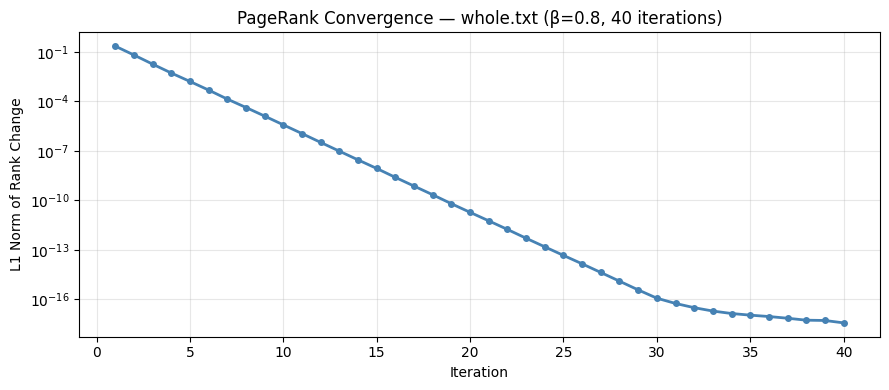

Plot saved as pagerank_convergence.png
  Final delta at iter 40: 3.79e-18  (near 0 = converged)


In [9]:
import matplotlib.pyplot as plt

def run_pagerank_with_tracking(links_rdd, n: int, beta: float = 0.8, num_iter: int = 40):
    teleport  = (1.0 - beta) / n
    ranks_rdd = links_rdd.mapValues(lambda _: 1.0 / n)
    delta_list = []

    for i in range(num_iter):
        prev_ranks = ranks_rdd  # Keep reference to previous ranks

        joined = links_rdd.join(ranks_rdd)
        contributions = joined.flatMap(
            lambda x: [
                (neighbor, x[1][1] / len(x[1][0]))
                for neighbor in x[1][0]
            ]
        )
        summed    = contributions.reduceByKey(lambda a, b: a + b)
        ranks_rdd = summed.mapValues(lambda c: teleport + beta * c)

        # Compute L1 change = sum |r_new - r_old|
        delta = ranks_rdd.join(prev_ranks) \
            .mapValues(lambda x: abs(x[0] - x[1])) \
            .values().sum()
        delta_list.append(delta)

        if (i + 1) % 10 == 0:
            ranks_rdd = ranks_rdd.cache()
            _ = ranks_rdd.count()

    return ranks_rdd, delta_list


# Run convergence tracking on the full graph
print("Running convergence analysis on whole.txt...")
t0 = time.time()
_, deltas = run_pagerank_with_tracking(links_whole, n=n_whole, beta=0.8, num_iter=40)
print(f"  Done in {time.time()-t0:.2f}s")

# Plot
plt.figure(figsize=(9, 4))
plt.plot(range(1, 41), deltas, marker='o', markersize=4, linewidth=2, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('L1 Norm of Rank Change')
plt.title('PageRank Convergence — whole.txt (β=0.8, 40 iterations)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pagerank_convergence.png', dpi=150)
plt.show()
print("Plot saved as pagerank_convergence.png")
print(f"  Final delta at iter 40: {deltas[-1]:.2e}  (near 0 = converged)")

## 8. Top-5 / Bottom-5 Summary



In [10]:
print("Top 5 nodes:")
for node, score in whole_sorted[:5]:
    print(node, score)

print("\nBottom 5 nodes:")
for node, score in whole_sorted[-5:]:
    print(node, score)

Top 5 nodes:
263 0.0020202911815182184
537 0.0019433415714531497
965 0.0019254478071662631
243 0.001852634016241731
285 0.0018273721700645144

Bottom 5 nodes:
408 0.00038779848719291705
424 0.00035481538649301454
62 0.00035314810510596274
93 0.00035135689375165774
558 0.0003286018525215297


In [11]:
# Stop Spark session
spark.stop()
print("Spark session stopped.")

Spark session stopped.
